In [2]:
%load_ext autoreload
%autoreload 2

# Cross-Subject Baseline Evaluation / 被験者間ベースラインモデル評価

This notebook explores the characteristics of multiple subjects after preprocessing and evaluates how well a baseline machine learning model generalizes to unseen subjects. The experiments provide an initial assessment of cross-subject performance before introducing more comprehensive evaluation strategies such as Leave-One-Subject-Out (LOSO) cross-validation.

---

# 被験者間ベースラインモデル評価

本ノートブックでは、前処理後の複数被験者のデータを分析し、ベースライン機械学習モデルが未知の被験者に対してどの程度汎化できるかを評価する。また、後続の Leave-One-Subject-Out（LOSO）交差検証による包括的な評価を行う前の基礎的な被験者間性能を確認する。

# Imports / インポート

This notebook imports reusable modules that handle each stage of the HAR pipeline.

このノートブックでは、HAR パイプラインの各処理を担当するモジュールを読み込みます。

### Modules Included / 読み込むモジュール
- Data loading / データ読み込み
- Configuration / 設定
- Preprocessing / 前処理
- Feature engineering / 特徴量生成
- Model evaluation / モデル評価
- Visualization / 可視化

In [ ]:
from har_utils.data import get_subject
from har_utils.config import FILE_NAME_SUFFIX, MODEL_HISTORY
from har_utils.preprocessing import (
    do_sanity_check, 
    preprocessing_pipeline
)
from har_utils.visualization import (
    plot_class_distribution,
    plot_compare_feature_side_by_side,
    plot_percentage_distribution,
)

from har_utils.analysis import predict_supervised

import joblib

import random as rnd

import pandas as pd

## Load Dataset / データセットの読み込み

Load the pose estimation data for each subject into a dictionary, where the subject ID is used as the key. Display the shape of each dataset to verify that all files were loaded successfully.

各被験者の姿勢推定データを辞書に読み込み、被験者IDをキーとして管理します。あわせて各データセットのサイズを表示し、正しく読み込まれたことを確認します。

In [9]:
# Load all subject datasets into a dictionary for easy access
# 各被験者のデータセットを辞書に読み込み、一括管理する
all_subject = {}

for suffix in FILE_NAME_SUFFIX:

    # Read the current subject dataset from the CSV file
    # 現在の被験者データをCSVファイルから読み込む
    all_subject[suffix] = get_subject(suffix)

    # Display the dataset dimensions to verify successful loading
    # データが正しく読み込まれたか、データサイズを確認する
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


## Data Sanity Check / データの健全性確認

Inspect each subject dataset before preprocessing to identify missing values, invalid entries, or other data quality issues.

前処理を行う前に、各被験者データを確認し、欠損値や異常値などのデータ品質の問題がないかを確認します。

In [11]:
# Perform a sanity check on all subject datasets before preprocessing.
# 前処理を行う前に、すべての被験者データの整合性を確認する。
sanity_summary = do_sanity_check(all_subject)

display(sanity_summary)

,Subject,Rows,Columns,NaN Count,Inf Count,Rows with NaN,Rows with Inf,Duplicate Rows
0,1,76456,35,3406,0,3406,0,3
1,2,74638,35,3388,0,3388,0,284
2,3,118087,35,11617,0,11617,0,1
3,5,75981,35,4161,0,4161,0,0


## Skeleton Normalization of All Subjects / 全被験者のスケルトン正規化

This section applies the preprocessing pipeline up to the **normalization stage** for every subject. The resulting normalized datasets are used for data inspection and subsequent feature engineering in later experiments.

---

## 全被験者のスケルトン正規化

このセクションでは、各被験者に対して前処理パイプラインを**正規化段階まで**適用する。得られた正規化データは、データ確認および後続の特徴量生成実験で使用する。

In [13]:
# Apply the preprocessing pipeline to every subject dataset.
# 各被験者データに前処理パイプラインを適用する。
all_subject_norm = {}

for suffix in FILE_NAME_SUFFIX:

    # Execute the complete preprocessing pipeline for the current subject.
    # 現在の被験者に対して完全な前処理パイプラインを実行する。
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix], return_stage='normalized')

    # Display the resulting dataset shape and summary statistics.
    # 前処理後データの形状と要約統計量を表示する。
    print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
    print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")

Subject_1 Shape: (73050, 35)
Description of Subject_1:
                    count  mean   std    min   25%   50%   75%    max
nose_x            73050.0 -0.00  0.40  -3.41 -0.41  0.08  0.27   2.19
nose_y            73050.0 -1.28  0.24  -1.62 -1.41 -1.36 -1.28   3.47
left_eye_x        73050.0  0.01  0.40  -2.79 -0.36  0.09  0.27   2.38
left_eye_y        73050.0 -1.37  0.25  -1.70 -1.50 -1.46 -1.36   3.33
right_eye_x       73050.0 -0.08  0.40  -3.77 -0.43 -0.05  0.21   1.96
right_eye_y       73050.0 -1.34  0.25  -1.62 -1.47 -1.43 -1.35   3.24
left_ear_x        73050.0 -0.04  0.36  -2.07 -0.29  0.02  0.25   2.82
left_ear_y        73050.0 -1.40  0.21  -1.77 -1.52 -1.46 -1.37   2.34
right_ear_x       73050.0 -0.26  0.36  -3.77 -0.39 -0.22 -0.03   1.34
right_ear_y       73050.0 -1.30  0.23  -1.53 -1.43 -1.40 -1.33   1.89
left_shoulder_x   73050.0 -0.02  0.34  -2.44 -0.32  0.05  0.28   4.92
left_shoulder_y   73050.0 -1.05  0.15  -1.49 -1.15 -1.05 -0.96   1.87
right_shoulder_x  73050.0 -0.37  0.

## Comparison of Original and Normalized Skeleton Features / 元データと正規化データの特徴量比較

To verify the effect of skeleton normalization, a randomly selected feature is visualized for each subject before and after normalization. This qualitative comparison helps confirm that the normalization preserves the temporal motion patterns while reducing subject-specific positional differences.

---

## 元データと正規化データの特徴量比較

スケルトン正規化の効果を確認するため、各被験者についてランダムに選択した特徴量を正規化前後で比較する。これにより、時間的な動作パターンを維持しつつ、被験者固有の位置の違いが低減されていることを視覚的に確認する。

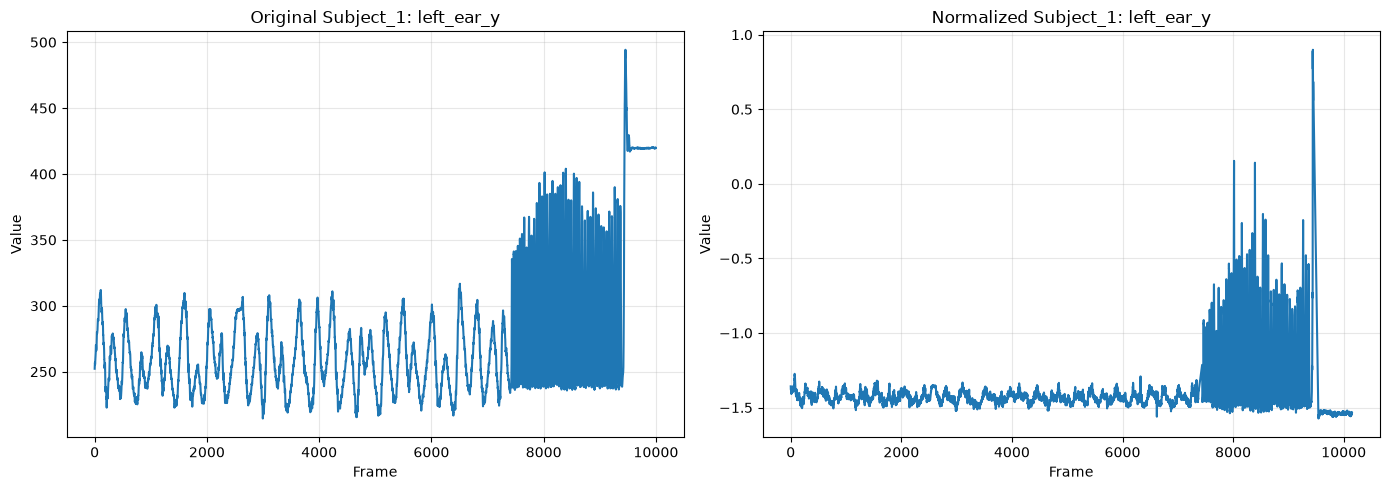

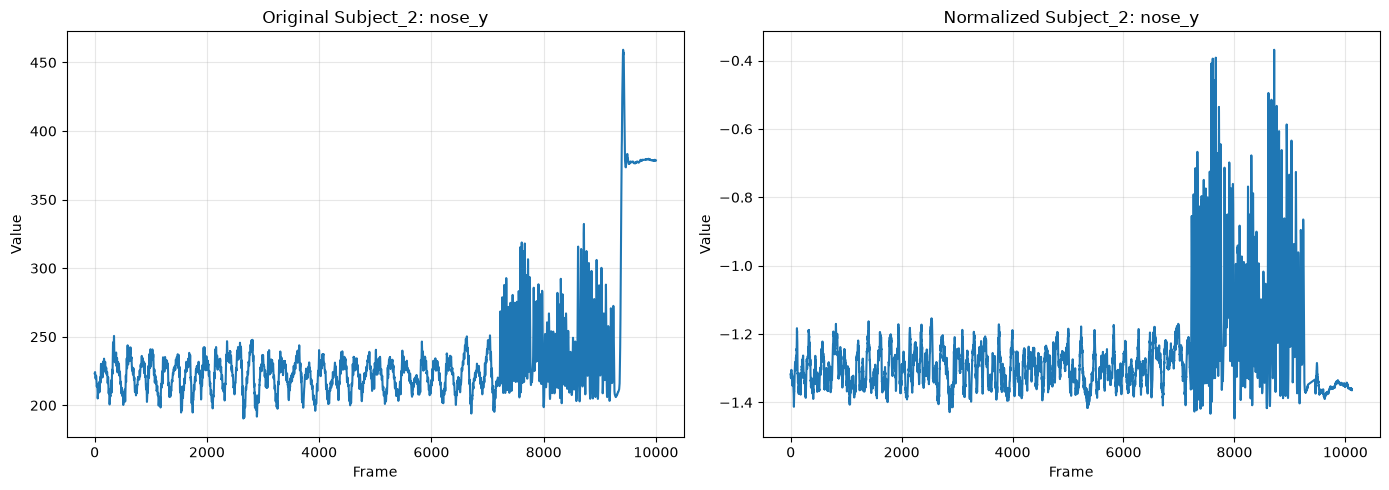

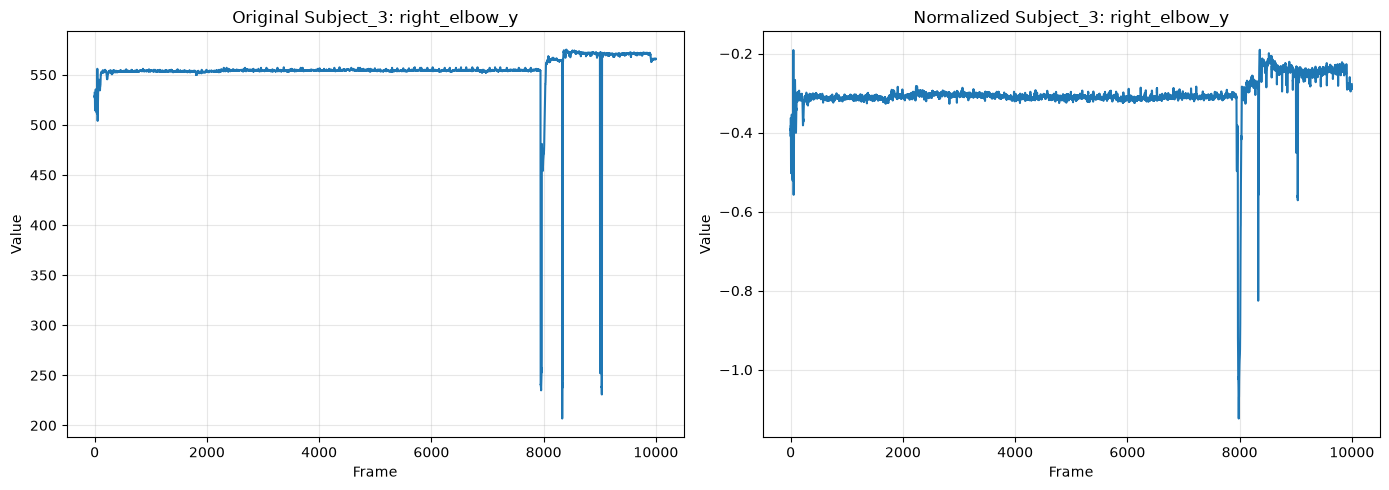

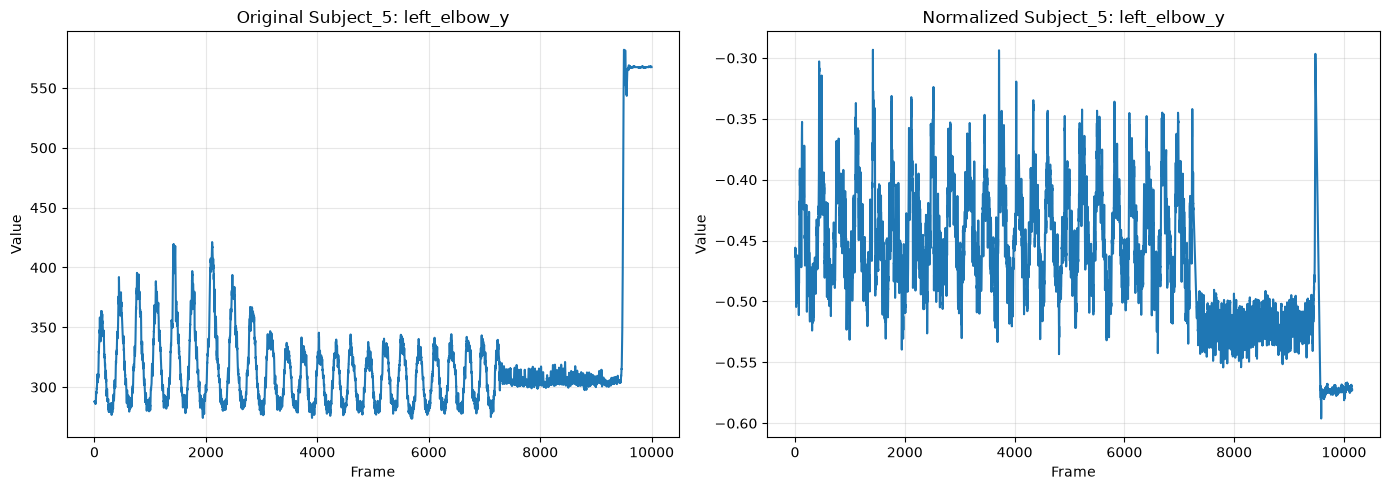

In [35]:
# Set a fixed random seed to ensure reproducible feature selection.
# 再現性を確保するため、乱数シードを固定する。
rnd.seed(42)

# Retrieve all feature columns except the activity label.
# 活動ラベルを除いたすべての特徴量列を取得する。
feature_cols = [
    col for col in all_subject[FILE_NAME_SUFFIX[0]].columns
    if col != 'Action Label'
]

for suffix in FILE_NAME_SUFFIX:

    # Randomly select one feature for visualization.
    # 可視化する特徴量をランダムに1つ選択する。
    rnd_feature = rnd.choice(feature_cols)

    # Compare the selected feature before and after skeleton normalization.
    # 選択した特徴量について、正規化前後を比較する。
    plot_compare_feature_side_by_side(
        all_subject[suffix],
        all_subject_norm[suffix],
        rnd_feature,
        f"Subject_{suffix}",
        start=0,
        end=10000
    )

    print("\n\n")

## Class Distribution Across All Subjects / 全被験者のクラス分布

The distribution of activity classes is visualized for each subject to examine class imbalance and identify differences in the number of frames collected for each activity.

---

## 全被験者のクラス分布

各被験者における活動クラスの分布を可視化し、クラス不均衡や活動ごとのフレーム数の違いを確認する。

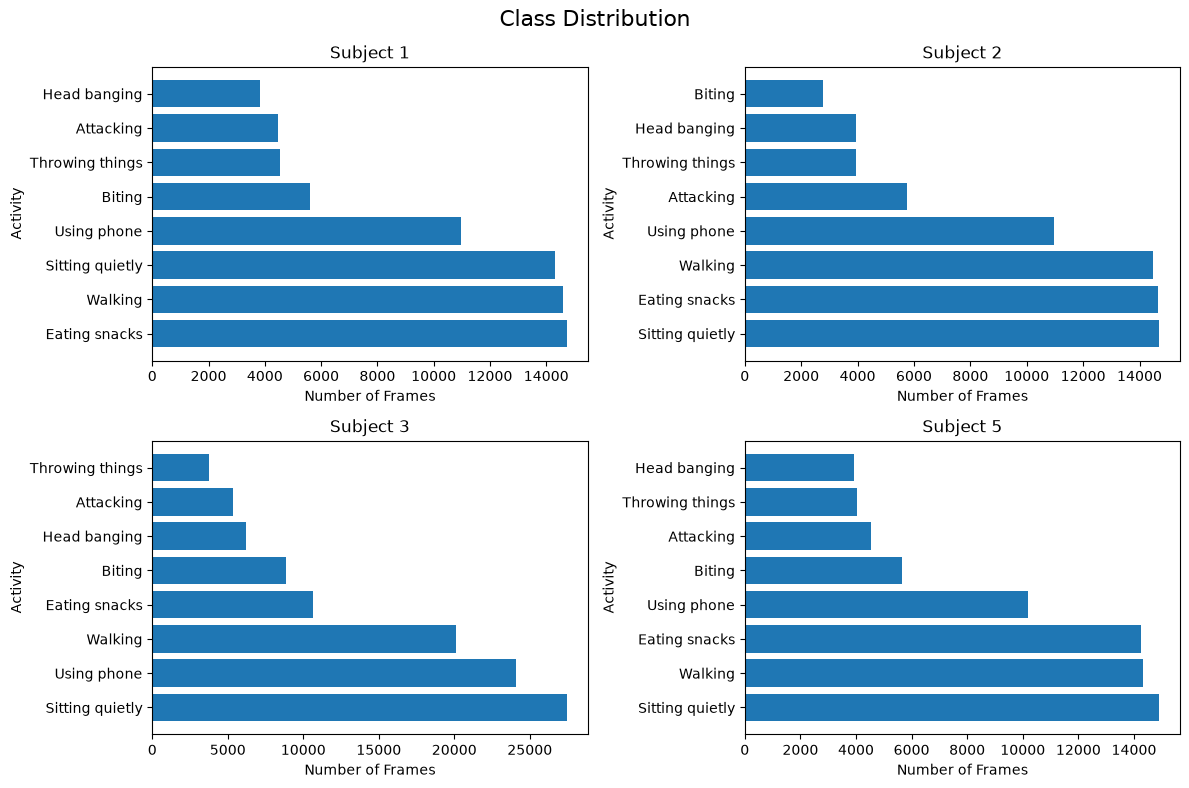

In [39]:
plot_class_distribution(all_subject_norm)

## Percentage Distribution Across All Subjects / 全被験者の割合分布

The relative percentage of each activity class is visualized for every subject. This allows comparison of the class composition independent of the total number of recorded frames.

---

## 全被験者の割合分布

各被験者における活動クラスの割合を可視化する。総フレーム数の違いに依存せず、活動クラスの構成比を比較する。

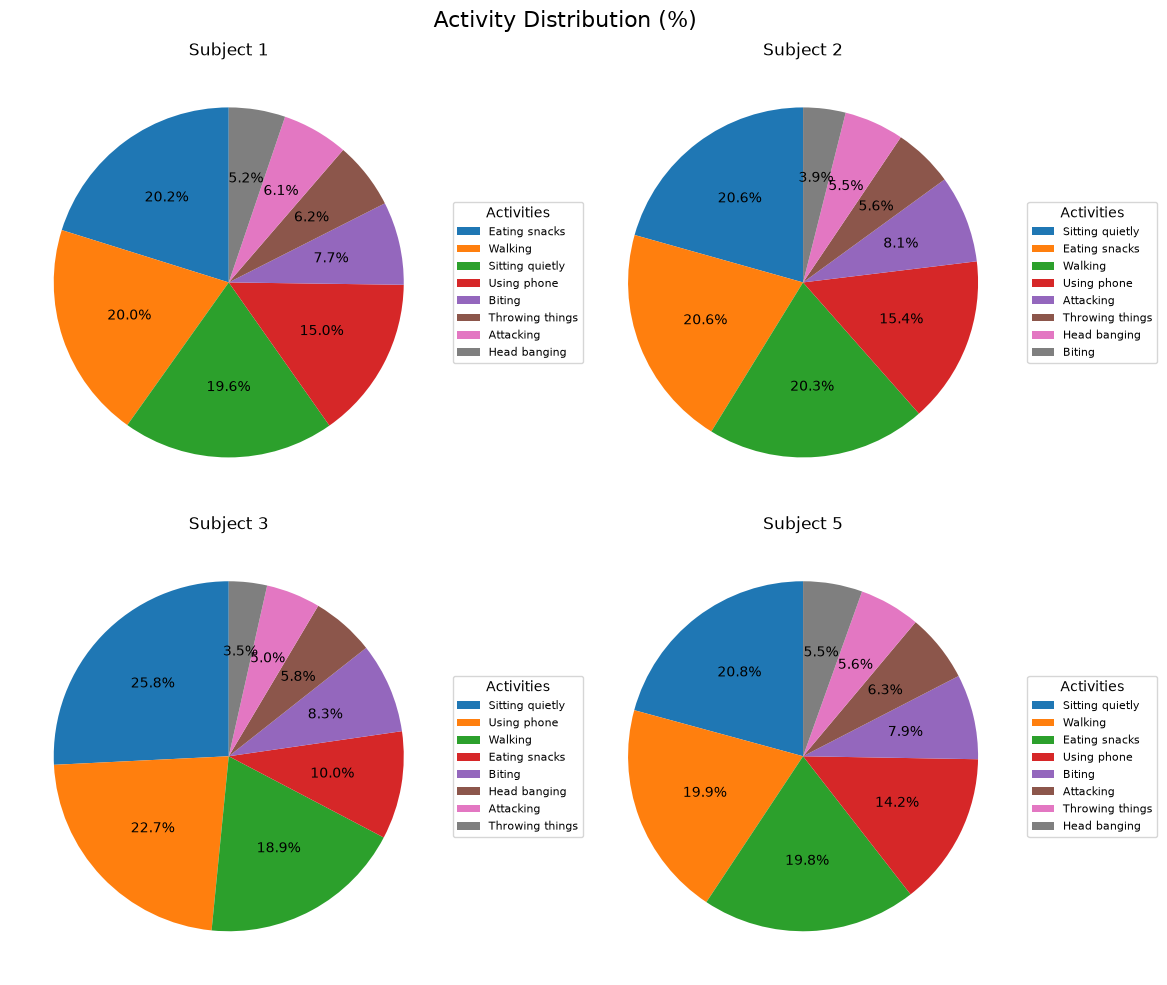

In [41]:
plot_percentage_distribution(all_subject_norm)

## Baseline Cross-Subject Evaluation / ベースライン被験者間評価

A Random Forest baseline model trained using **Subject 1** is evaluated on unseen subjects without additional training. These experiments assess the model's ability to generalize across different individuals before introducing subject-independent evaluation methods such as Leave-One-Subject-Out (LOSO) cross-validation.

---

## ベースライン被験者間評価

**Subject 1** のデータで学習した Random Forest ベースラインモデルを、追加学習なしで未知の被験者に適用する。LOSO（Leave-One-Subject-Out）交差検証による評価を行う前に、被験者間の汎化性能を確認する。

### Subject 1 → Subject 2

The baseline model trained on **Subject 1** is evaluated using **Subject 2** as the unseen test subject.

---

### Subject 1 → Subject 2

**Subject 1** で学習したベースラインモデルを、未知の被験者である **Subject 2** を用いて評価する。

/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parall


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.00      0.00      0.00      5760
         Biting       0.00      0.00      0.00      2790
  Eating snacks       0.16      0.00      0.00     14670
   Head banging       0.00      0.00      0.00      3930
Sitting quietly       0.00      0.00      0.00     14700
Throwing things       0.87      0.18      0.30      3960
    Using phone       0.17      1.00      0.29     10980
        Walking       0.94      0.41      0.57     14460

       accuracy                           0.25     71250
      macro avg       0.27      0.20      0.15     71250
   weighted avg       0.30      0.25      0.18     71250


********************************************************************

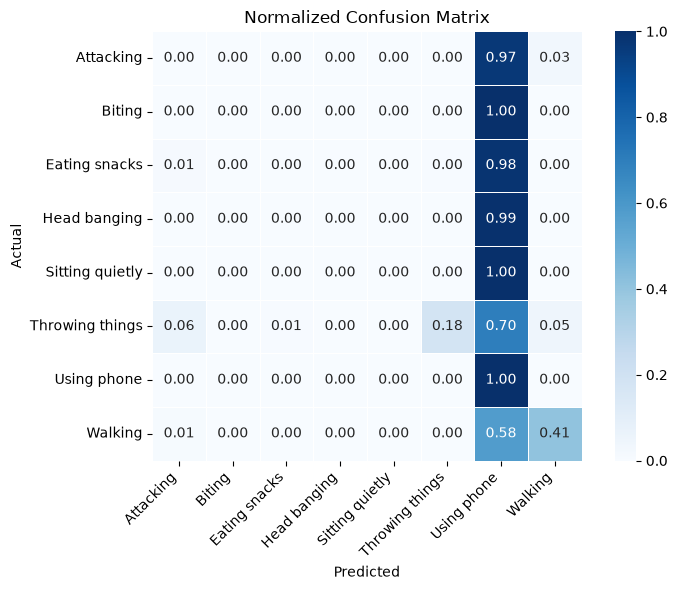

In [ ]:
# Importing the model
rf = joblib.load(MODEL_HISTORY / "random_forest_subject_one.pkl")

subject2_X = all_subject_norm[FILE_NAME_SUFFIX[1]].drop(columns=['Action Label'])
subject2_y = all_subject_norm[FILE_NAME_SUFFIX[1]]['Action Label']

predict_supervised(subject2_X, subject2_y, model=rf)

### Subject 1 → Subject 3

The baseline model trained on **Subject 1** is evaluated using **Subject 3** as the unseen test subject.

---

### Subject 1 → Subject 3

**Subject 1** で学習したベースラインモデルを、未知の被験者である **Subject 3** を用いて評価する。

/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parall


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.58      0.71      0.64      5340
         Biting       0.00      0.00      0.00      8880
  Eating snacks       0.15      0.00      0.00     10620
   Head banging       0.00      0.00      0.00      6210
Sitting quietly       0.00      0.00      0.00     27450
Throwing things       0.62      0.11      0.19      3750
    Using phone       0.26      0.95      0.41     24120
        Walking       0.73      0.45      0.55     20100

       accuracy                           0.34    106470
      macro avg       0.29      0.28      0.22    106470
   weighted avg       0.26      0.34      0.24    106470


********************************************************************

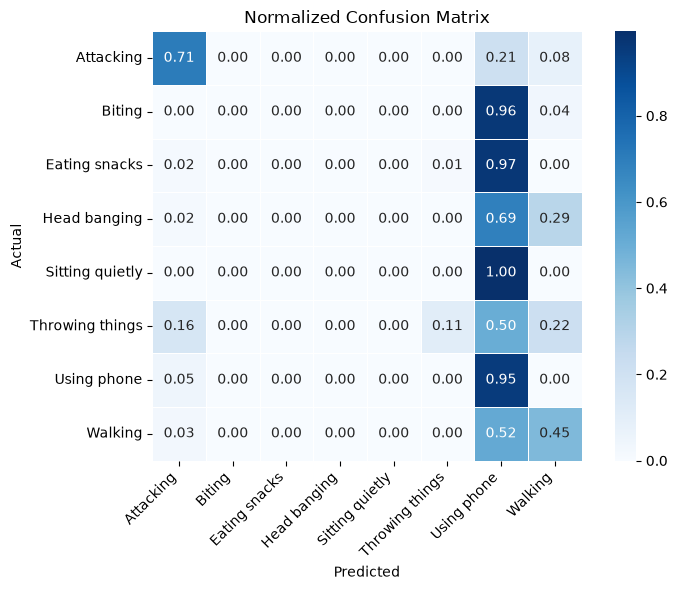

In [45]:
# Importing the model
rf = joblib.load(MODEL_HISTORY / "random_forest_subject_one.pkl")

subject3_X = all_subject_norm[FILE_NAME_SUFFIX[2]].drop(columns=['Action Label'])
subject3_y = all_subject_norm[FILE_NAME_SUFFIX[2]]['Action Label']

predict_supervised(subject3_X, subject3_y, model=rf)

### Subject 1 → Subject 5

The baseline model trained on **Subject 1** is evaluated using **Subject 5** as the unseen test subject.

---

### Subject 1 → Subject 5

**Subject 1** で学習したベースラインモデルを、未知の被験者である **Subject 5** を用いて評価する。

/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parall


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.49      0.60      0.54      4530
         Biting       0.01      0.00      0.00      5640
  Eating snacks       0.00      0.00      0.00     14250
   Head banging       0.00      0.00      0.00      3930
Sitting quietly       0.20      0.22      0.21     14910
Throwing things       0.99      0.33      0.49      4050
    Using phone       0.16      0.58      0.26     10200
        Walking       0.84      0.43      0.57     14310

       accuracy                           0.27     71820
      macro avg       0.34      0.27      0.26     71820
   weighted avg       0.32      0.27      0.26     71820


********************************************************************

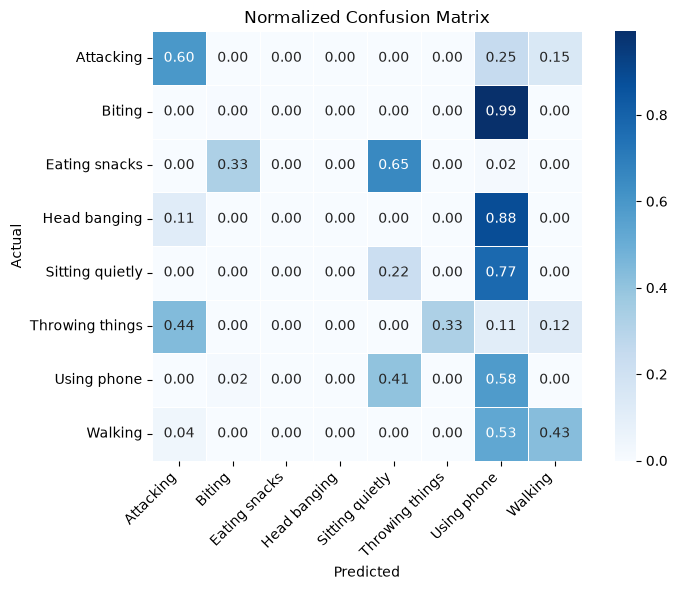

In [44]:
# Importing the model
rf = joblib.load(MODEL_HISTORY / "random_forest_subject_one.pkl")

subject5_X = all_subject_norm[FILE_NAME_SUFFIX[3]].drop(columns=['Action Label'])
subject5_y = all_subject_norm[FILE_NAME_SUFFIX[3]]['Action Label']

predict_supervised(subject5_X, subject5_y, model=rf)

### Subject 1 → Subjects 2, 3, and 5

The baseline model trained on **Subject 1** is evaluated on the combined data from **Subjects 2, 3, and 5**. This experiment provides an overall measure of the model's ability to generalize to multiple unseen subjects.

---

### Subject 1 → Subjects 2・3・5

**Subject 1** で学習したベースラインモデルを、**Subject 2・3・5** の結合データで評価する。この実験では、複数の未知被験者に対するモデルの総合的な汎化性能を確認する。

/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parall


********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.51      0.41      0.46     15630
         Biting       0.01      0.00      0.00     17310
  Eating snacks       0.14      0.00      0.00     39540
   Head banging       0.00      0.00      0.00     14070
Sitting quietly       0.20      0.06      0.09     57060
Throwing things       0.87      0.21      0.34     11760
    Using phone       0.21      0.88      0.34     45300
        Walking       0.81      0.43      0.56     48870

       accuracy                           0.29    249540
      macro avg       0.34      0.25      0.22    249540
   weighted avg       0.34      0.29      0.24    249540


********************************************************************

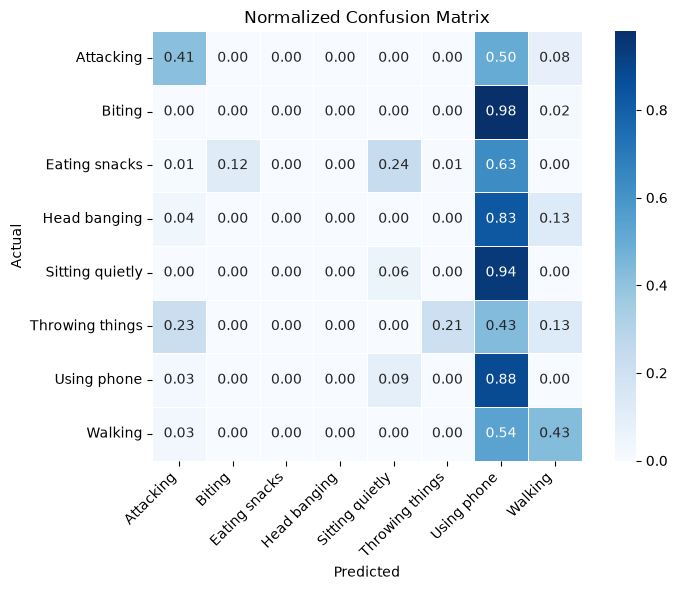

In [47]:
# Importing the model
rf = joblib.load(MODEL_HISTORY / "random_forest_subject_one.pkl")

# Combine Subjects 2, 3, and 5 into a single test dataset.
# Subject 2・3・5を結合して1つのテストデータセットを作成する。
subject235 = pd.concat(
    [
        all_subject_norm[FILE_NAME_SUFFIX[1]],
        all_subject_norm[FILE_NAME_SUFFIX[2]],
        all_subject_norm[FILE_NAME_SUFFIX[3]]
    ],
    ignore_index=True
)

# Separate features and labels.
# 特徴量とラベルを分離する。
subject235_X = subject235.drop(columns=['Action Label'])
subject235_y = subject235['Action Label']

# Evaluate the baseline model.
# ベースラインモデルを評価する。
predict_supervised(subject235_X, subject235_y, model=rf)

## Results Summary / 結果の概要

### Performance Comparison / 性能比較

| Test Subject | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|--------------|---------:|----------------:|-------------:|---------:|
| Subject 2 | **25%** | 0.27 | 0.20 | **0.15** |
| Subject 3 | **34%** | 0.29 | 0.28 | **0.22** |
| Subject 5 | **27%** | **0.34** | 0.27 | **0.26** |
| Subjects 2 + 3 + 5 | **29%** | **0.34** | 0.25 | **0.22** |

---

### Key Observations / 主な考察

- The baseline model trained on **Subject 1** showed **limited cross-subject generalization**, with Macro F1-scores ranging from **0.15 to 0.26**.
- **Subject 5** achieved the highest overall performance (Macro F1 = **0.26**), while **Subject 2** produced the lowest (Macro F1 = **0.15**).
- The combined evaluation on **Subjects 2, 3, and 5** resulted in a **Macro F1-score of 0.22**, indicating that the baseline model does not generalize well when deployed to multiple unseen subjects.
- Activities such as **Walking** and **Using phone** were recognized relatively well across most subjects, whereas **Biting**, **Head banging**, and **Eating snacks** consistently exhibited poor recognition performance.
- These results suggest that a model trained using data from a single subject is insufficient for robust subject-independent human activity recognition.

---

### まとめ

#### 性能比較

| テスト被験者 | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|-------------|---------:|----------------:|-------------:|---------:|
| Subject 2 | **25%** | 0.27 | 0.20 | **0.15** |
| Subject 3 | **34%** | 0.29 | 0.28 | **0.22** |
| Subject 5 | **27%** | **0.34** | 0.27 | **0.26** |
| Subject 2・3・5 | **29%** | **0.34** | 0.25 | **0.22** |

#### 主な考察

- **Subject 1** のみで学習したベースラインモデルは、未知の被験者に対して十分な汎化性能を示さなかった（Macro F1 = **0.15～0.26**）。
- **Subject 5** が最も高い性能（Macro F1 = **0.26**）を示し、**Subject 2** が最も低い性能（Macro F1 = **0.15**）となった。
- **Subject 2・3・5** を統合した評価では Macro F1 は **0.22** に留まり、複数の未知被験者に対する性能も限定的であった。
- **Walking** および **Using phone** は比較的高い認識性能を示した一方、**Biting**、**Head banging**、**Eating snacks** はほとんど認識できなかった。
- 以上の結果から、単一被験者のみで学習したモデルでは被験者間の汎化性能が不十分であり、LOSO 交差検証や特徴量設計、モデル最適化が必要であることが示された。